# Práctica Final: Clasificación con Scikit-learn y MLflow

En esta práctica, utilizarás un conjunto de datos de Scikit-learn (podeís usar el mismo que en el notebook de Intro MLFlow) para entrenar un modelo de clasificación.

Pasos a seguir: 

    Exploración de Datos: Analiza el conjunto de datos proporcionado para comprender su estructura y contenido.


    Entrenamiento del Modelo: Utiliza algoritmos de ML o DL para entrenar un modelo con los datos preprocesados.

    Evaluación del Modelo: Evalúa el rendimiento del modelo utilizando métricas de evaluación estándar como precisión y recall.

    Registro de Métricas con MLflow: Utiliza MLflow para registrar métricas y hiperparámetros durante el entrenamiento, facilitando la gestión y comparación de experimentos.


Nota: Dado que no voy a poder tener acceso a vuestros logs de MLFlow añadirme las imagenes de la interfaz de MLFlow en el notebook

In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 1. Exploración de datos
# Usamos el mismo dataset que en el notebook de Intro a MLflow cáncer de mama
cancer = load_breast_cancer()
df = pd.DataFrame(cancer["data"], columns=cancer["feature_names"])
df["target"] = cancer["target"]   # 0 = maligno, 1 = benigno

print("Dimensiones del dataset:", df.shape)
print("\nDistribución de clases (0=maligno, 1=benigno):")
print(df["target"].value_counts())
print("\nValores nulos en total:", int(df.isnull().sum().sum()))
df.head()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dimensiones del dataset: (569, 31)

Distribución de clases (0=maligno, 1=benigno):
target
1    357
0    212
Name: count, dtype: int64

Valores nulos en total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Estadísticas descriptivas para entender escalas y rangos de las features
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [3]:
# 2. Preparación de datos: split estratificado train/test 
features = [c for c in df.columns if c != "target"]
X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (455, 30)  Test: (114, 30)


In [4]:
# 3. Entrenamiento y evaluación del modelo 
# usamos un Gradient Boosting:

preprocessor = Pipeline(steps=[("scaler", StandardScaler())])
clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
model = Pipeline(steps=[("preprocessor", preprocessor), ("GradientBoosting", clf)])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy train:", round(model.score(X_train, y_train), 4))
print("Accuracy test :", round(accuracy_score(y_test, y_pred), 4))
print("Precision     :", round(precision_score(y_test, y_pred), 4))
print("Recall        :", round(recall_score(y_test, y_pred), 4))
print("F1-score      :", round(f1_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))


Accuracy train: 1.0
Accuracy test : 0.9561
Precision     : 0.9467
Recall        : 0.9861
F1-score      : 0.966

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Matriz de confusión:
 [[38  4]
 [ 1 71]]


In [9]:
# 4. Registro de experimentos con MLflow 
# registramos precision, recall y f1, varios hiperparámetros y guardamos el modelo con su
# signature e input_example

from mlflow.models.signature import infer_signature

mlflow.set_experiment("breast-cancer-gradient-boosting")

param_grid = [
    {"n_estimators": 50,  "learning_rate": 0.10, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.10, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 2},
]

for params in param_grid:
    clf = GradientBoostingClassifier(random_state=42, **params)
    model = Pipeline(steps=[
        ("preprocessor", Pipeline(steps=[("scaler", StandardScaler())])),
        ("GradientBoosting", clf),
    ])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metrics = {
        "accuracy_train": model.score(X_train, y_train),
        "accuracy_test": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

    # Nombre descriptivo del run con sus hiperparámetros para distinguirlos en la UI
    run_name = f"gb_n{params['n_estimators']}_lr{params['learning_rate']}_d{params['max_depth']}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        signature = infer_signature(X_test, y_pred)
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            signature=signature,
            input_example=X_test.iloc[:2],
        )

    print(params, "->", {k: round(v, 4) for k, v in metrics.items()})


2026/06/19 12:34:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 12:34:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/19 12:34:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 12:34:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 2} -> {'accuracy_train': 0.9956, 'accuracy_test': 0.9386, 'precision': 0.9452, 'recall': 0.9583, 'f1': 0.9517}
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3} -> {'accuracy_train': 1.0, 'accuracy_test': 0.9561, 'precision': 0.9467, 'recall': 0.9861, 'f1': 0.966}


2026/06/19 12:34:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 12:34:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3} -> {'accuracy_train': 1.0, 'accuracy_test': 0.9561, 'precision': 0.9467, 'recall': 0.9861, 'f1': 0.966}


2026/06/19 12:34:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 12:34:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2} -> {'accuracy_train': 1.0, 'accuracy_test': 0.9474, 'precision': 0.9459, 'recall': 0.9722, 'f1': 0.9589}


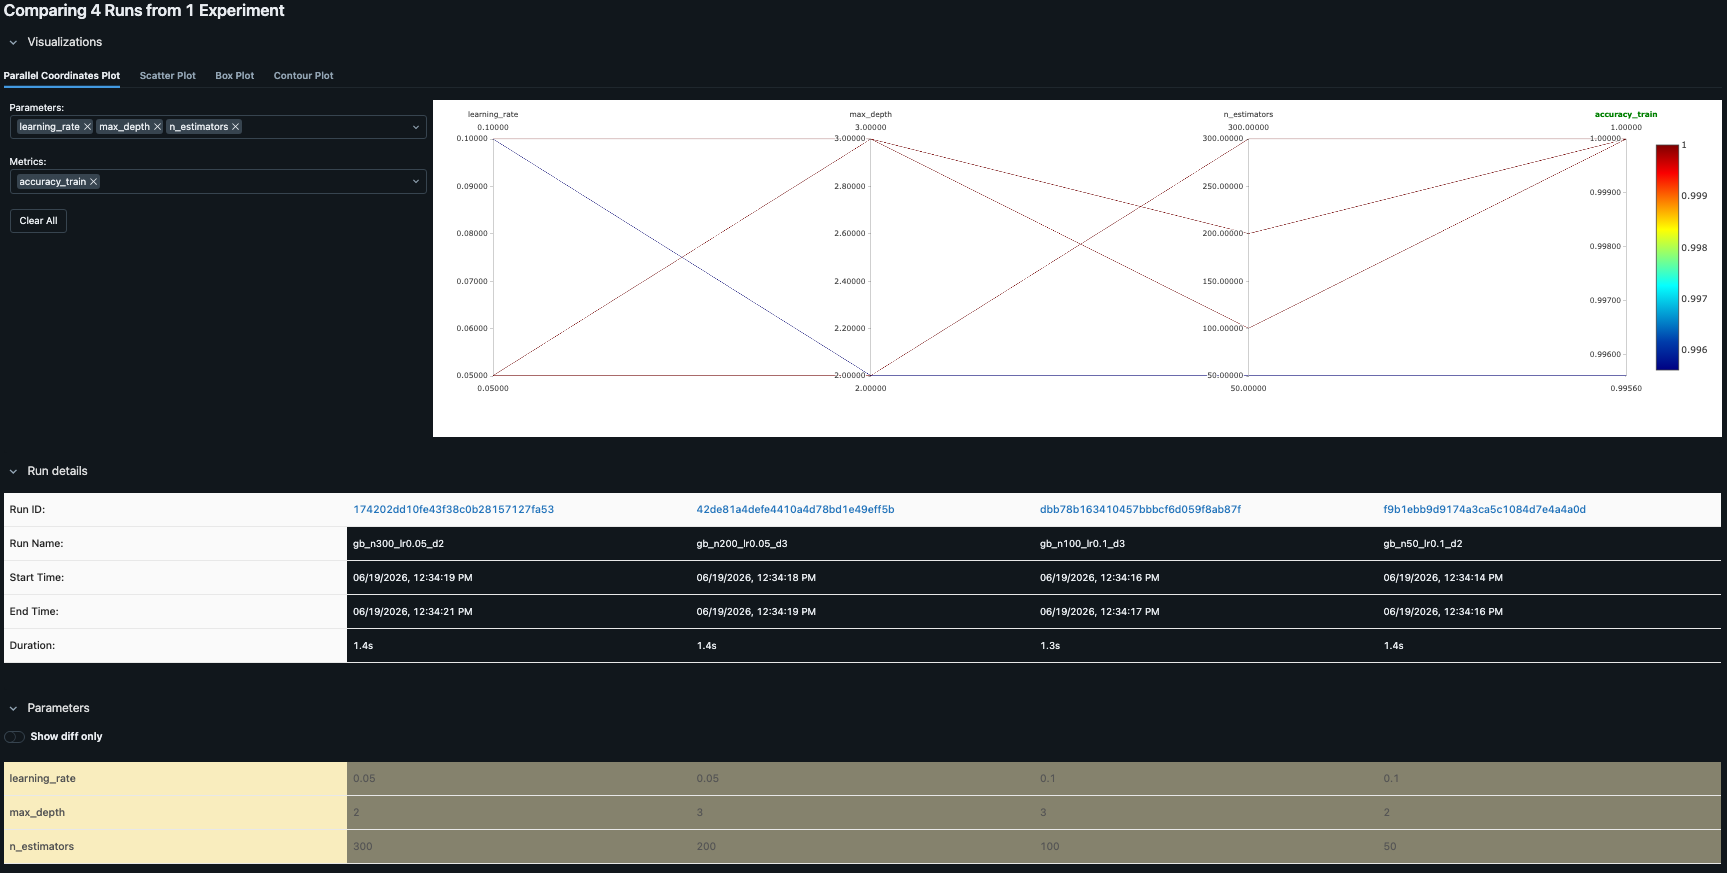

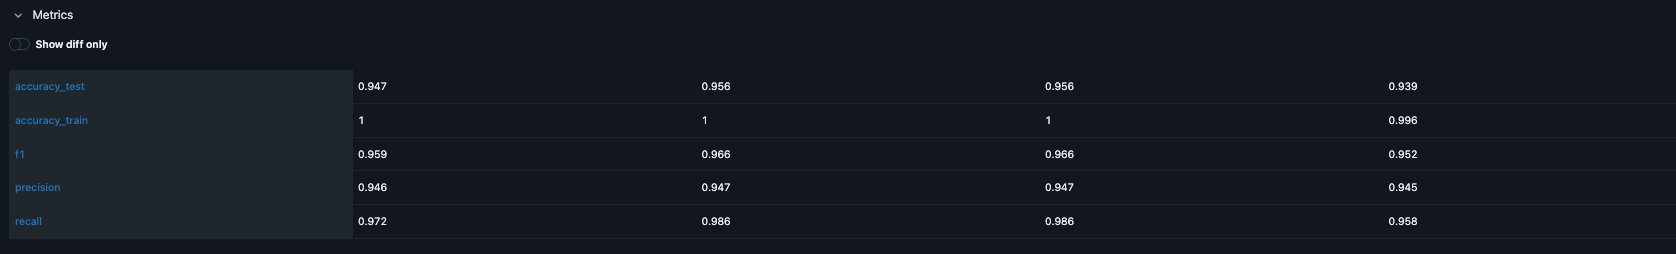

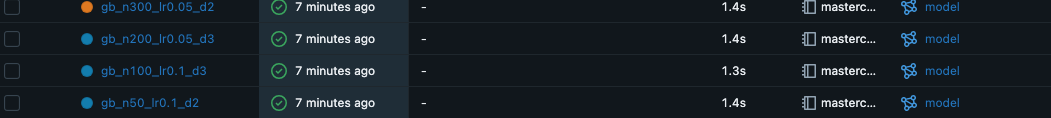

## Práctica parte FastAPI

### Para esta parte de la práctica teneis que generar un script con al menos 5 modulos app.get y dos de ellos tienen que ser pipelines de HF. 

### Parte de la practica se tendra que entregar en capturas de pantalla. Las capturas de pantalla a adjuntas son las siguientes. 

### 1. Captura de la pantalla docs con al menos 5 modulos. 
### 2. Captura de cada una de los modulos con la respuesta dentro de docs. 
### 3. Captura de cada uno de los modulos en la llamada https.
### 4. Todo el codigo usado durante el proceso. Notebooks y scripts.

### Opcional

### 5. Despliegue del script en GCP Cloud Run

In [ ]:
%%writefile practica_api.py
from collections import Counter
from functools import lru_cache

from fastapi import FastAPI
from transformers import pipeline

app = FastAPI(title="Práctica Despliegue - API")


# Las pipelines de Hugging Face se cargan una sola vez (cache) la primera vez
# que se llama a cada endpoint, para no recargar el modelo en cada petición.
@lru_cache(maxsize=None)
def get_pipeline(task: str):
    return pipeline(task)


# 1. Endpoint sencillo: estadísticas básicas de un texto (sin modelo)
@app.get("/info-texto")
def info_texto(texto: str):
    palabras = texto.split()
    return {
        "num_palabras": len(palabras),
        "num_caracteres": len(texto),
        "palabra_mas_larga": max(palabras, key=len) if palabras else "",
    }


# 2. Endpoint: palabras más frecuentes de un texto (sin modelo)
@app.get("/palabras-frecuentes")
def palabras_frecuentes(texto: str, top: int = 3):
    palabras = [p.lower().strip(".,;:!?\"'()") for p in texto.split()]
    conteo = Counter(p for p in palabras if p)
    return {"top": [{"palabra": w, "veces": n} for w, n in conteo.most_common(top)]}


# 3. Endpoint que invierte un texto (sin modelo)
@app.get("/invertir")
def invertir(texto: str):
    return {"original": texto, "invertido": texto[::-1]}


# 4. Endpoint con pipeline de Hugging Face: rellenar la palabra oculta
#    El texto debe contener el token <mask>, ej: "Paris is the <mask> of France"
@app.get("/rellenar")
def rellenar(texto: str):
    pipe = get_pipeline("fill-mask")
    return [
        {"opcion": r["token_str"].strip(), "score": float(r["score"]), "frase": r["sequence"]}
        for r in pipe(texto)
    ]


# 5. Endpoint con pipeline de Hugging Face: reconocimiento de entidades (NER)
@app.get("/entidades")
def entidades(texto: str):
    pipe = get_pipeline("ner")
    # Convertimos los scores (numpy.float32) a float nativo para serializar a JSON
    return [
        {k: (float(v) if k == "score" else v) for k, v in ent.items()}
        for ent in pipe(texto)
    ]


Overwriting practica_api.py


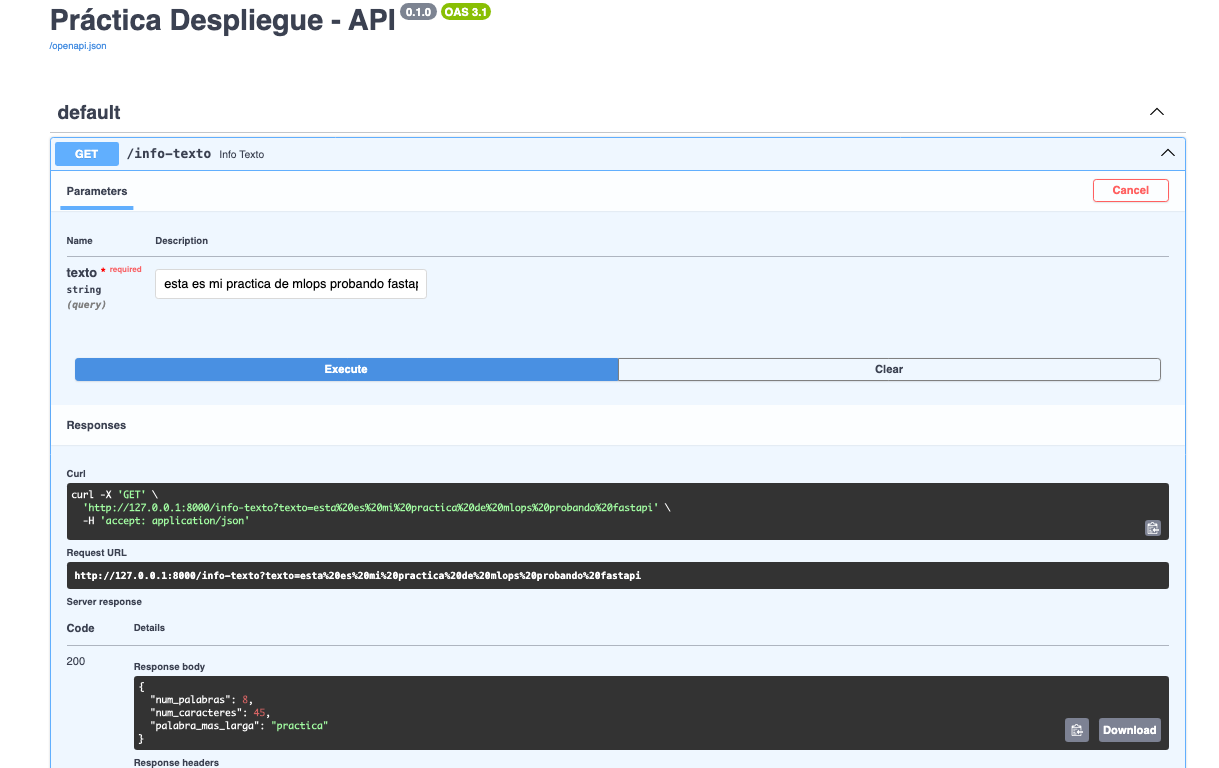

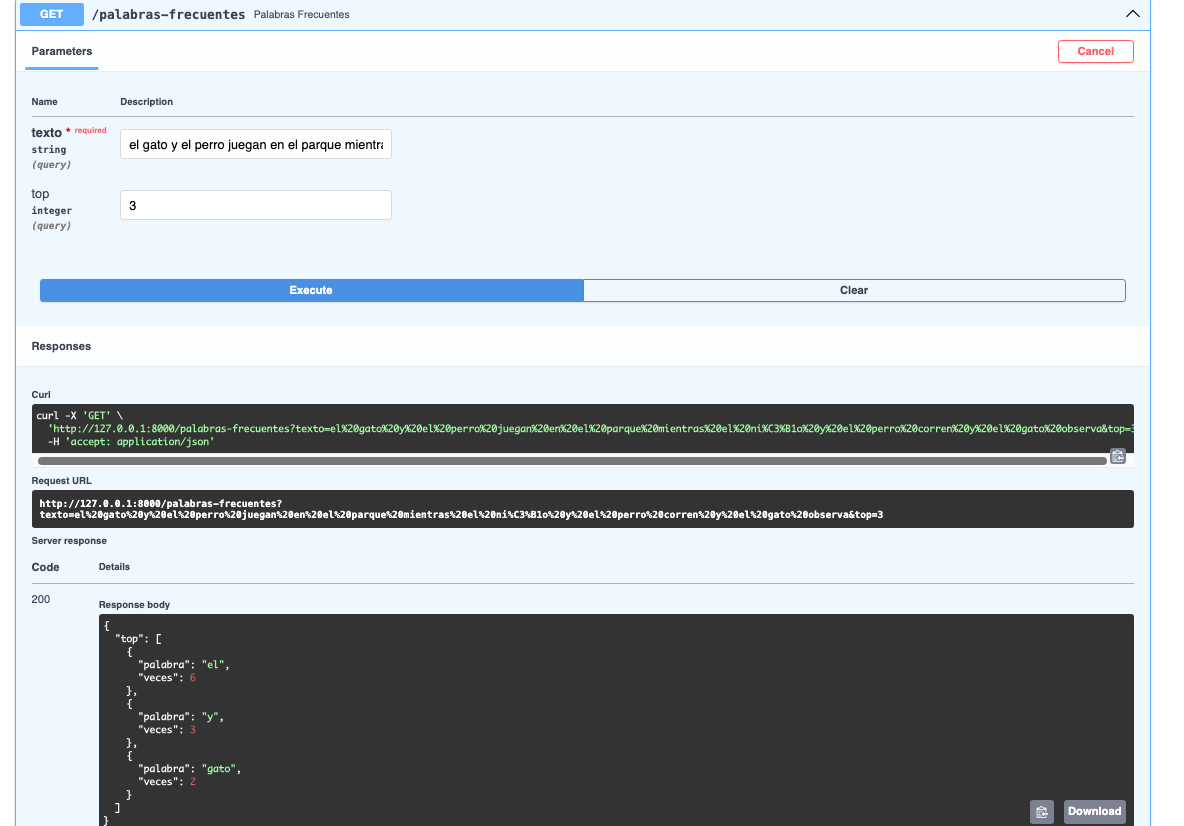

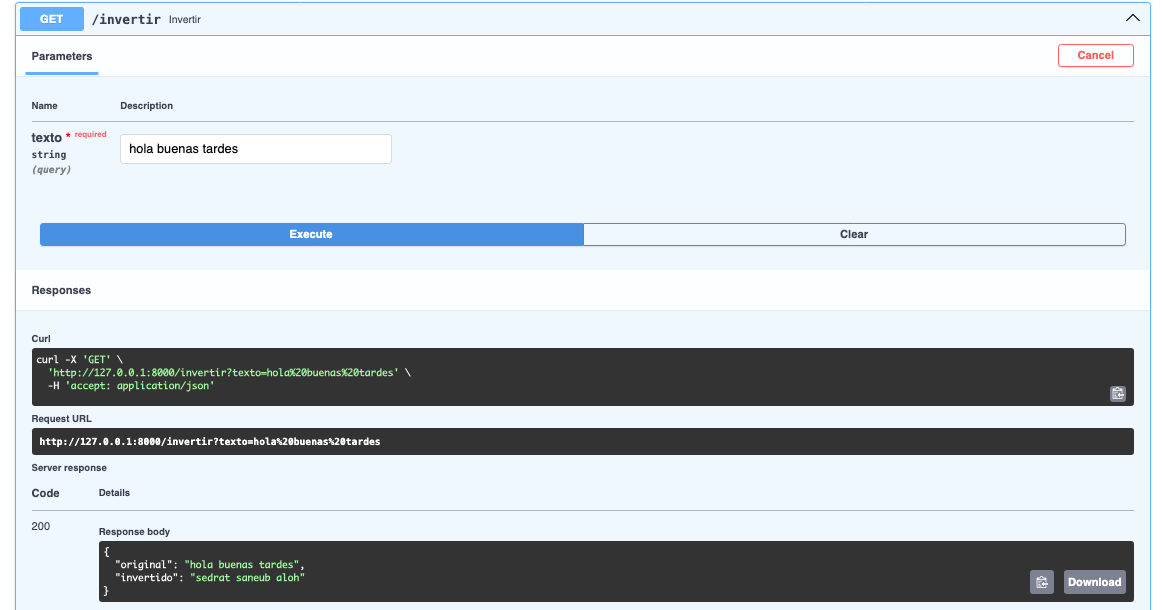

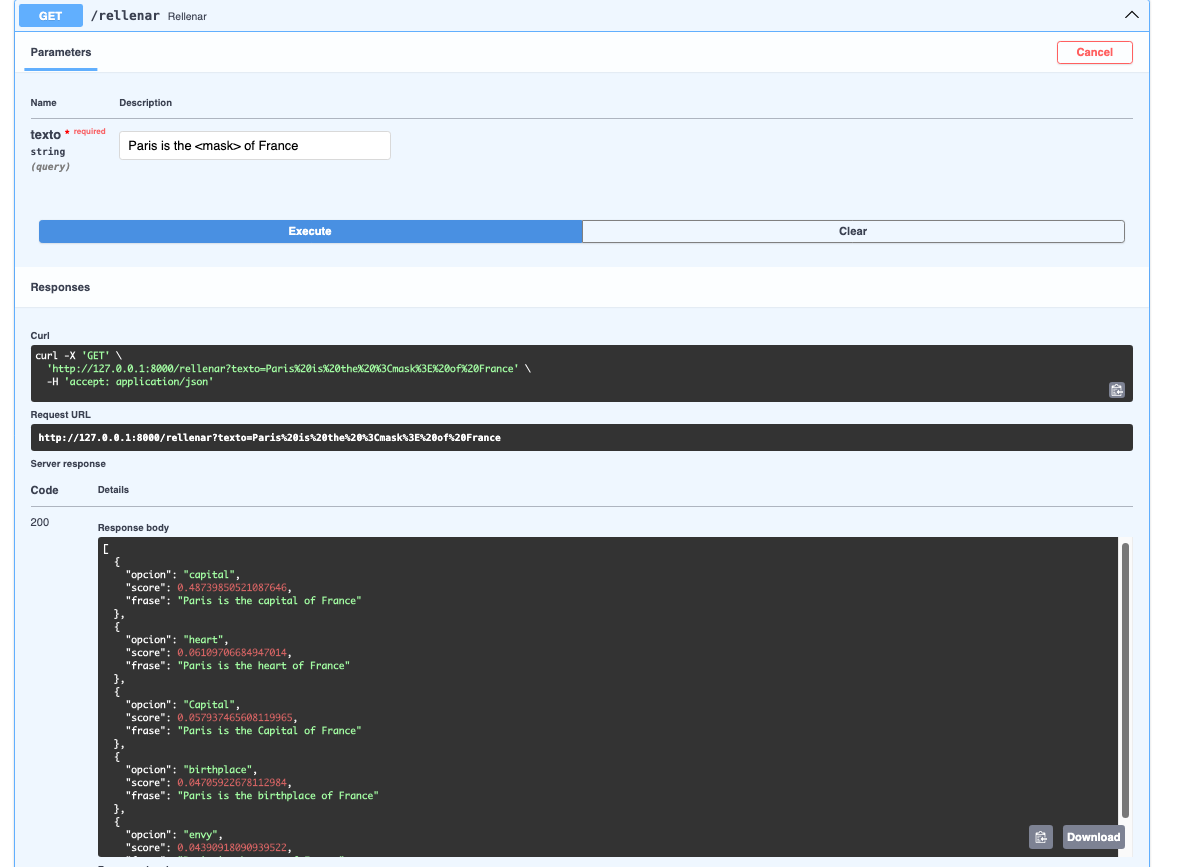

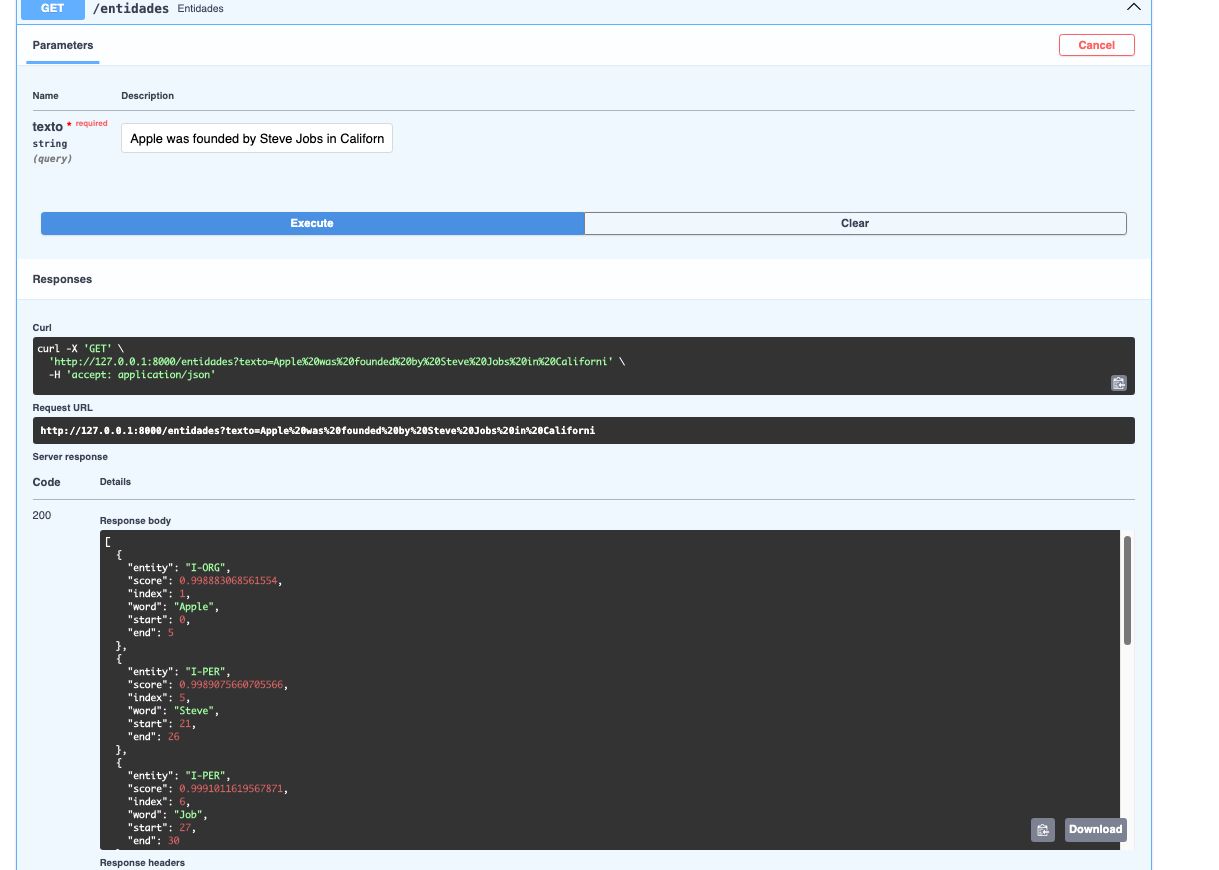